In [9]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [10]:
relative_benign_path= "data\\processed\\Modbus Dataset\\benign\\ied1a\\MODBUS_ONLY_veth4edc015-normal-4.csv"
relative_attack_path = "data\\processed\\Modbus Dataset\\attack\\compromised-scada\\ied1a\\MODBUS_ONLY_veth3614724-0.csv"  # Example attack file

absolute_benign_path = (Path("../..") / relative_benign_path).resolve()
absolute_compromised_scada_attack_path = (Path("../..") / relative_attack_path).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_benign_path)
print("Absolute path to compromised SCADA attack data:", absolute_compromised_scada_attack_path)

Absolute path to clean data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\benign\ied1a\MODBUS_ONLY_veth4edc015-normal-4.csv
Absolute path to compromised SCADA attack data: C:\Users\jorel\OneDrive\Documents\CODE STUFF\DOE\BNL\foundational_model_for_energy_security\data\processed\Modbus Dataset\attack\compromised-scada\ied1a\MODBUS_ONLY_veth3614724-0.csv


In [11]:
benign_data = pd.read_csv(absolute_benign_path)
attack_data = pd.read_csv(absolute_compromised_scada_attack_path)

attack_data_copy = attack_data.copy()

print(benign_data.columns.tolist())
print(f"Shape of attack data: {attack_data.shape}")
display(attack_data.head())

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'tcp_stream', 'tcp_time_delta', 'tcp_flags', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'request_frame', 'response_frame', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label']
Shape of attack data: (151443, 48)


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,tcp_stream,...,SYN,RST,PSH,ACK,URG,inter_arrival_time,time_from_start,requests_per_second,round_trip_time,label
0,4,1.678846e+09,2023-03-15 02:01:05.333506+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,34210,502,12,0,...,0,0,1,1,0,NaN,0.000000,1,0.040260,NORMAL
1,6,1.678846e+09,2023-03-15 02:01:05.373766+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,34210,11,0,...,0,0,1,1,0,0.040260,0.040260,1,0.040260,NORMAL
2,12,1.678846e+09,2023-03-15 02:01:05.394348+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,34222,502,12,1,...,0,0,1,1,0,0.020582,0.060842,2,0.058039,NORMAL
3,18,1.678846e+09,2023-03-15 02:01:05.452387+00:00,Modbus/TCP,185.175.0.4,185.175.0.3,502,34222,11,1,...,0,0,1,1,0,0.058039,0.118881,2,0.058039,NORMAL
4,24,1.678846e+09,2023-03-15 02:01:05.477443+00:00,Modbus/TCP,185.175.0.3,185.175.0.4,34228,502,12,3,...,0,0,1,1,0,0.025056,0.143937,3,0.071066,NORMAL


In [12]:
print(attack_data.dtypes)

packet_number            int64
timestamp              float64
datetime                object
protocols               object
src_ip                  object
dst_ip                  object
src_port                 int64
dst_port                 int64
tcp_len                  int64
tcp_stream               int64
tcp_time_delta         float64
tcp_flags               object
tcp_seq                  int64
tcp_ack                  int64
tcp_window_size          int64
tcp_retransmission       int64
tcp_duplicate_ack        int64
tcp_lost_segment         int64
tcp_out_of_order         int64
transaction_id           int64
protocol_id              int64
modbus_length            int64
unit_id                  int64
function_code            int64
reference_num          float64
word_count             float64
bit_count              float64
byte_count             float64
exception_code         float64
request_frame          float64
response_frame         float64
response_time          float64
pkt_len 

label_numeric          1.000000
function_code          0.777747
word_count             0.681178
requests_per_second    0.473911
is_request             0.455215
modbus_length          0.424827
bit_count              0.260445
tcp_len                0.147897
pkt_len                0.147897
round_trip_time        0.089705
tcp_seq                0.079247
FIN                    0.021401
byte_count             0.014584
response_time         -0.001879
tcp_time_delta        -0.002225
is_exception          -0.010551
inter_arrival_time    -0.141840
time_from_start       -0.231740
tcp_ack               -0.405351
is_response           -0.455215
tcp_window_size       -0.455218
reference_num         -0.912062
tcp_retransmission          NaN
tcp_duplicate_ack           NaN
tcp_lost_segment            NaN
tcp_out_of_order            NaN
protocol_id                 NaN
exception_code              NaN
SYN                         NaN
RST                         NaN
PSH                         NaN
ACK     

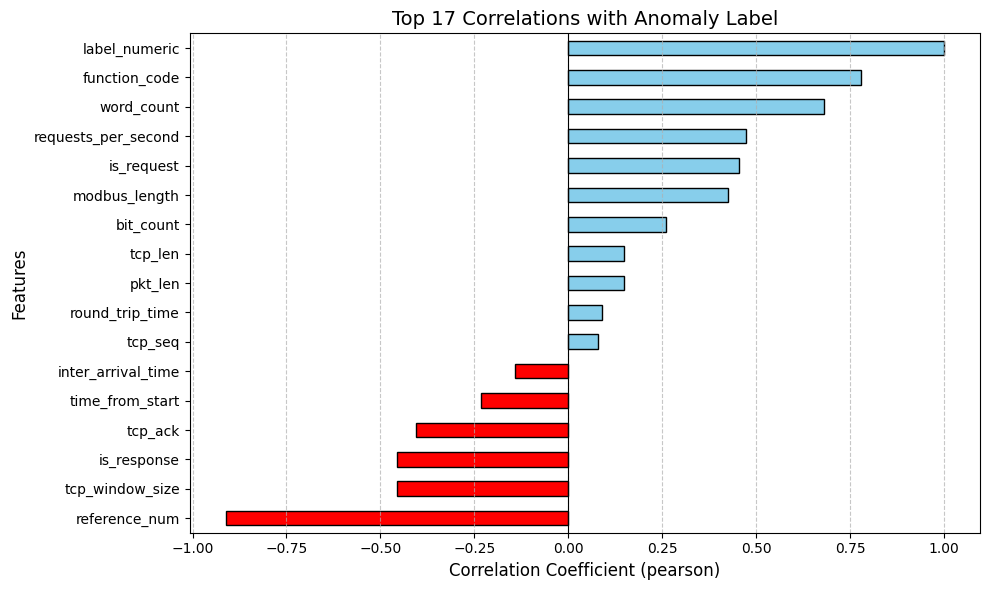

                     label_numeric
label_numeric             1.000000
reference_num            -0.912062
function_code             0.777747
word_count                0.681178
requests_per_second       0.473911
tcp_window_size          -0.455218
is_request                0.455215
is_response              -0.455215
modbus_length             0.424827
tcp_ack                  -0.405351
bit_count                 0.260445
time_from_start          -0.231740
tcp_len                   0.147897
pkt_len                   0.147897
inter_arrival_time       -0.141840
round_trip_time           0.089705
tcp_seq                   0.079247
label_numeric          1.000000
bit_count              0.949936
word_count             0.947159
function_code          0.796235
requests_per_second    0.740844
is_request             0.455215
pkt_len                0.445845
tcp_len                0.445845
modbus_length          0.445195
tcp_seq                0.085288
FIN                    0.021401
byte_count        

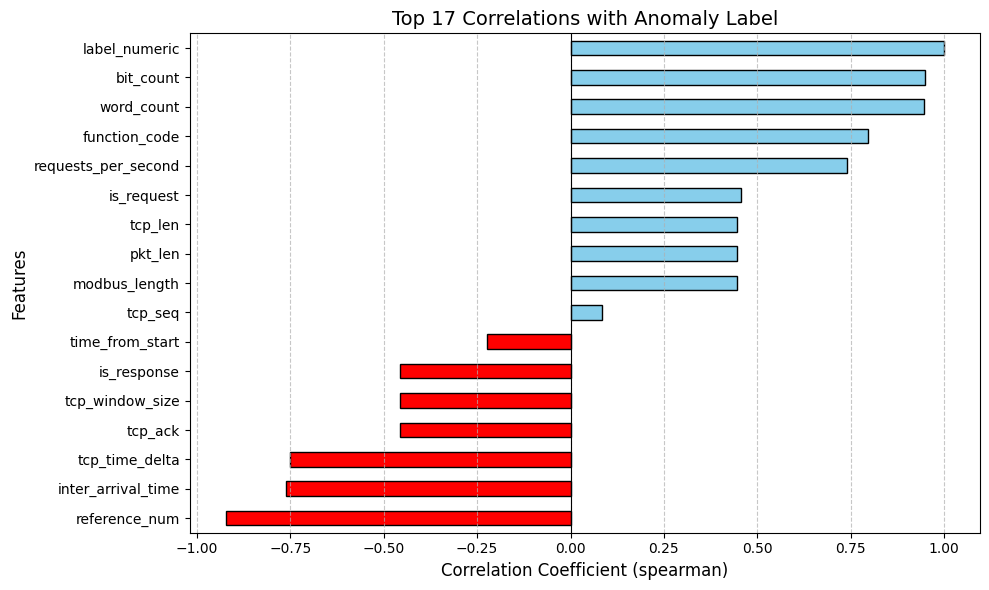

                     label_numeric
label_numeric             1.000000
bit_count                 0.949936
word_count                0.947159
reference_num            -0.923328
function_code             0.796235
inter_arrival_time       -0.762802
tcp_time_delta           -0.749686
requests_per_second       0.740844
tcp_ack                  -0.455442
tcp_window_size          -0.455218
is_request                0.455215
is_response              -0.455215
pkt_len                   0.445845
tcp_len                   0.445845
modbus_length             0.445195
time_from_start          -0.223837
tcp_seq                   0.085288
label_numeric          1.000000
bit_count              0.949668
word_count             0.946860
function_code          0.716849
requests_per_second    0.634883
is_request             0.455215
pkt_len                0.429648
tcp_len                0.429648
modbus_length          0.429168
tcp_seq                0.085214
FIN                    0.021401
byte_count        

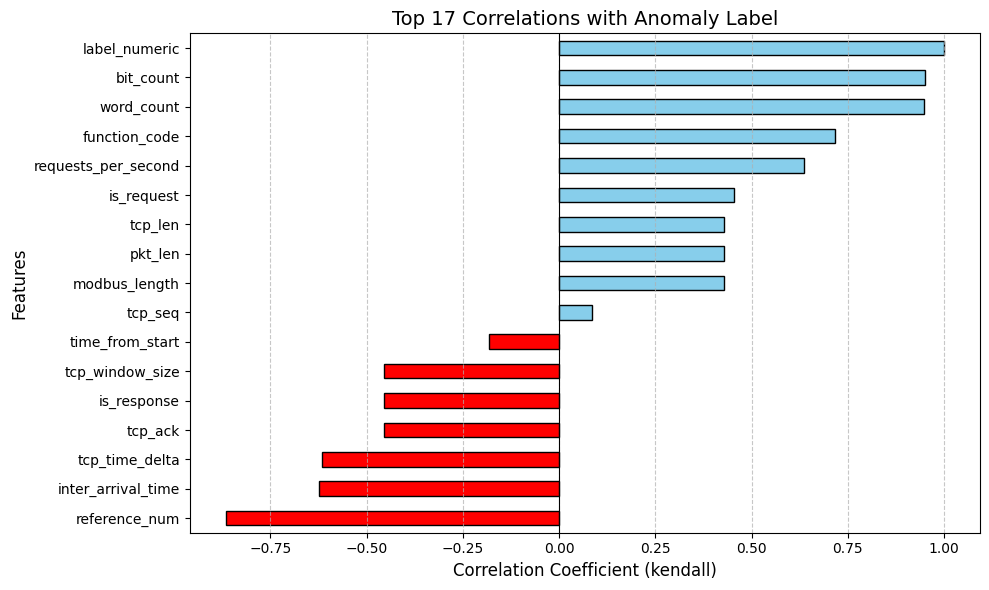

                     label_numeric
label_numeric             1.000000
bit_count                 0.949668
word_count                0.946860
reference_num            -0.866295
function_code             0.716849
requests_per_second       0.634883
inter_arrival_time       -0.623163
tcp_time_delta           -0.616646
tcp_ack                  -0.455330
is_request                0.455215
is_response              -0.455215
tcp_window_size          -0.455203
pkt_len                   0.429648
tcp_len                   0.429648
modbus_length             0.429168
time_from_start          -0.182762
tcp_seq                   0.085214


In [13]:
# Create numeric label FIRST (only if 'label' column exists)
if 'label' in attack_data.columns:
    attack_data['label_numeric'] = (attack_data['label'] == 'ANOMALY').astype(int)
if 'label' in benign_data.columns:
    benign_data['label_numeric'] = (benign_data['label'] == 'ANOMALY').astype(int)

# Then drop columns
columns_to_drop = [
    'packet_number',
    'timestamp',
    'datetime',
    'src_ip',
    'dst_ip',
    'src_port',
    'dst_port',
    'tcp_stream',
    'transaction_id',
    'protocols',
    'unit_id',
    'tcp_flags',
    'function_name',
    'label',              # Drop original label after creating numeric version
    'request_frame',
    'response_frame',
]

attack_data = attack_data.drop(columns=columns_to_drop, errors='ignore')

# Compare all three
for method in ['pearson', 'spearman', 'kendall']:
    target_variable = 'label_numeric'

    # Calculate correlations 
    correlations = attack_data.corr(method=method)[target_variable].sort_values(ascending=False)
    print(correlations)

    # Get top features by absolute value
    number_of_features = 17
    top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index

    # Get actual correlation values (not absolute)
    top_correlations = correlations[top_feature_names].sort_values(ascending=True)

    # Plot with color coding
    plt.figure(figsize=(10, 6))
    colors = ['red' if x < 0 else 'skyblue' for x in top_correlations]
    top_correlations.plot(kind='barh', color=colors, edgecolor='black')
    plt.title(f'Top {number_of_features} Correlations with Anomaly Label', fontsize=14)
    plt.xlabel(f'Correlation Coefficient ({method})', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)  # Add zero line
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Print with actual values
    print(correlations[top_feature_names].to_frame())

In [14]:
target_variable = 'label_numeric'
method = 'pearson'  # You can change this to 'spearman' or 'kendall' as needed

# Calculate correlations 
correlations = attack_data.corr(method=method)[target_variable].sort_values(ascending=False)

# Get top features by absolute value
number_of_features = 17
top_feature_names = correlations.abs().sort_values(ascending=False).head(number_of_features).index

print(list(top_feature_names))

['label_numeric', 'reference_num', 'function_code', 'word_count', 'requests_per_second', 'tcp_window_size', 'is_request', 'is_response', 'modbus_length', 'tcp_ack', 'bit_count', 'time_from_start', 'tcp_len', 'pkt_len', 'inter_arrival_time', 'round_trip_time', 'tcp_seq']


In [15]:
print(attack_data.columns.tolist())

['tcp_len', 'tcp_time_delta', 'tcp_seq', 'tcp_ack', 'tcp_window_size', 'tcp_retransmission', 'tcp_duplicate_ack', 'tcp_lost_segment', 'tcp_out_of_order', 'protocol_id', 'modbus_length', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'response_time', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'FIN', 'SYN', 'RST', 'PSH', 'ACK', 'URG', 'inter_arrival_time', 'time_from_start', 'requests_per_second', 'round_trip_time', 'label_numeric']


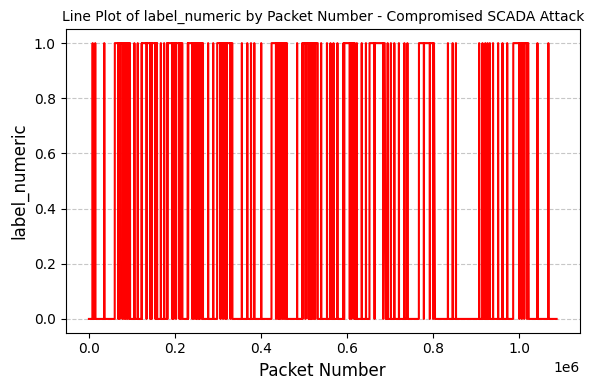

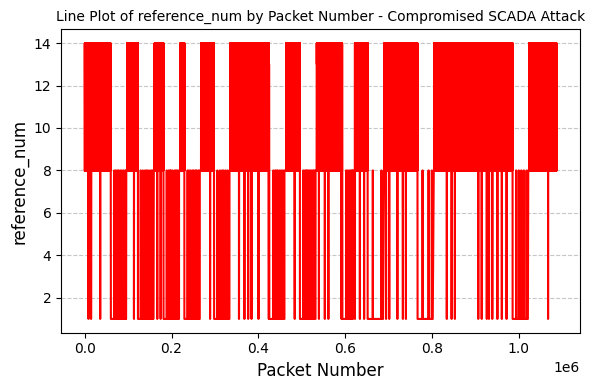

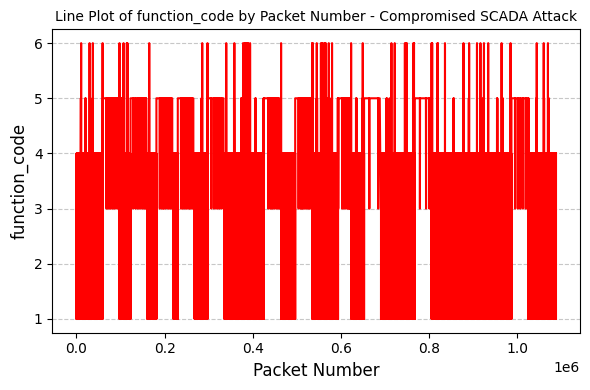

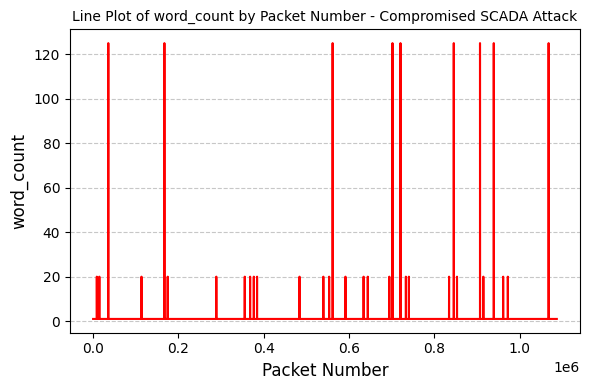

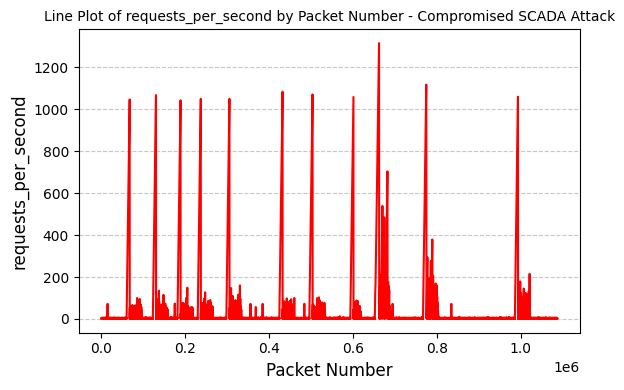

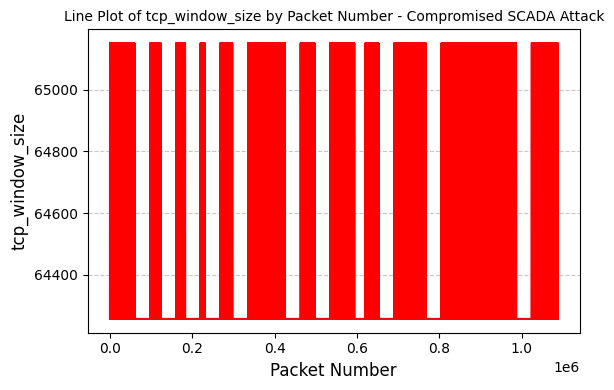

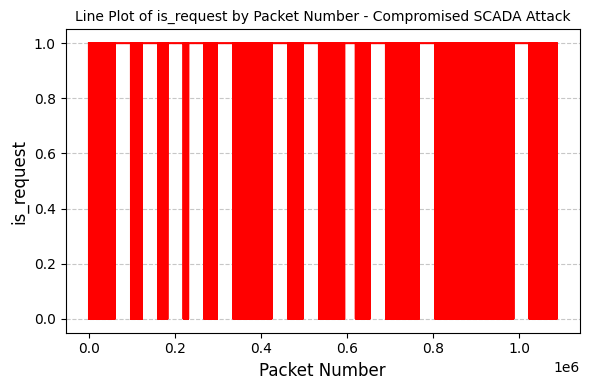

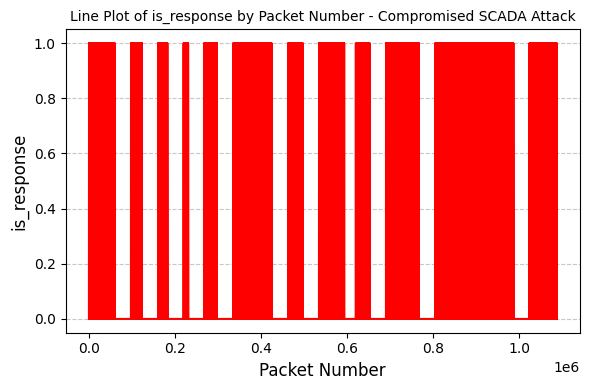

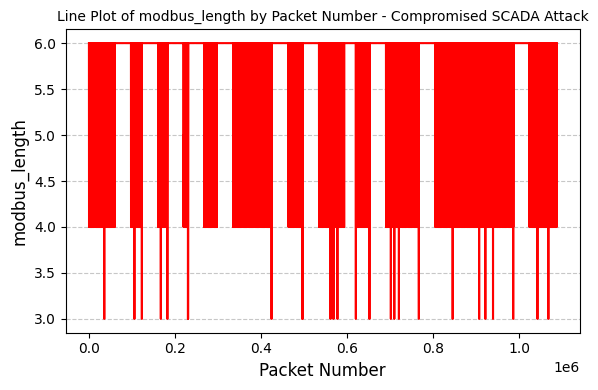

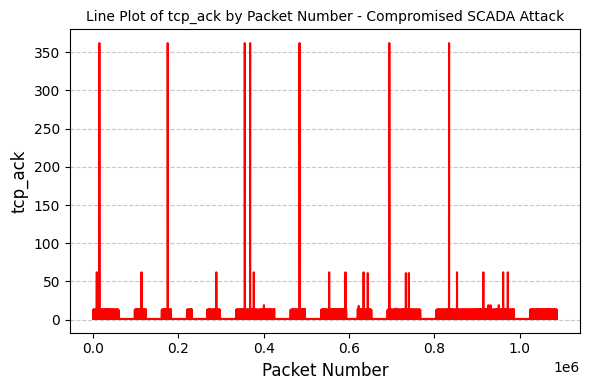

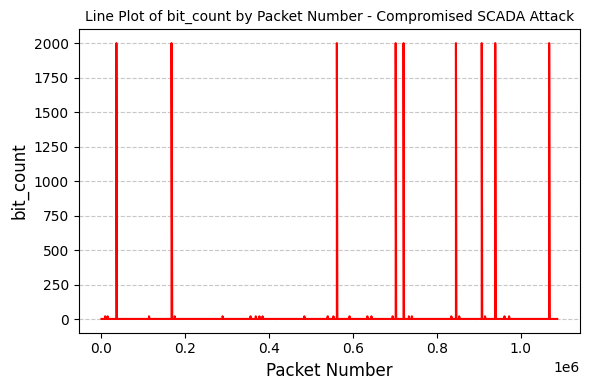

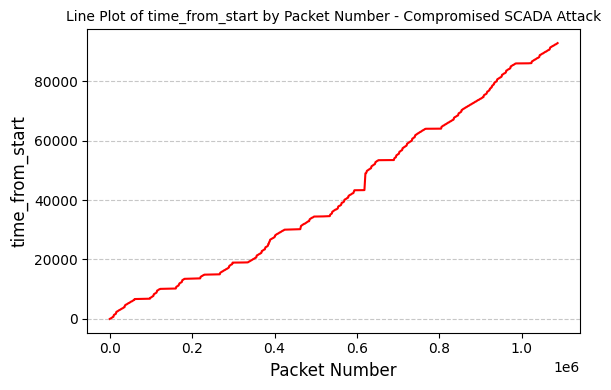

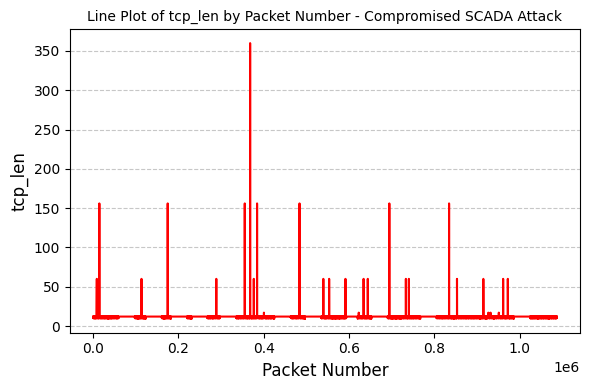

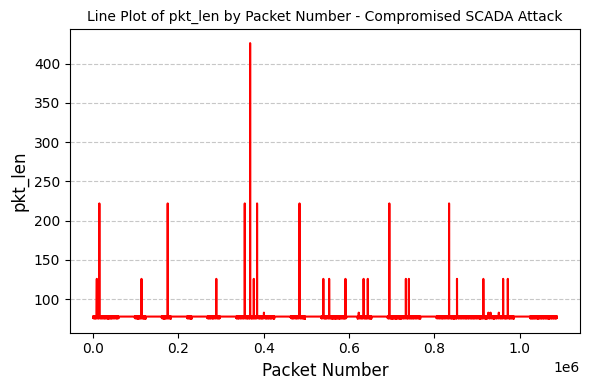

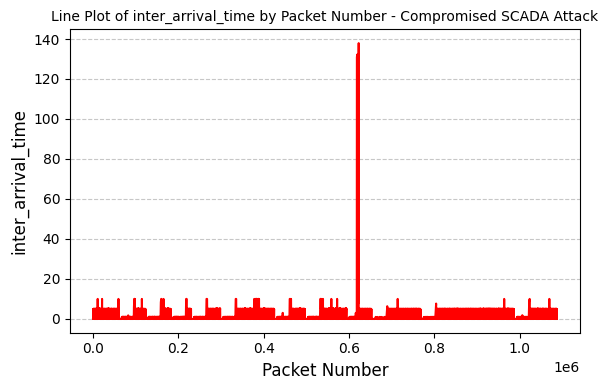

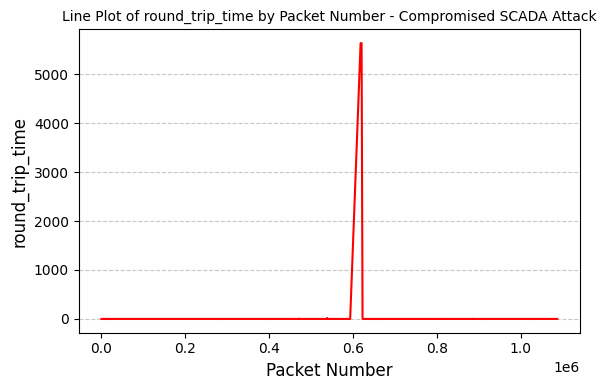

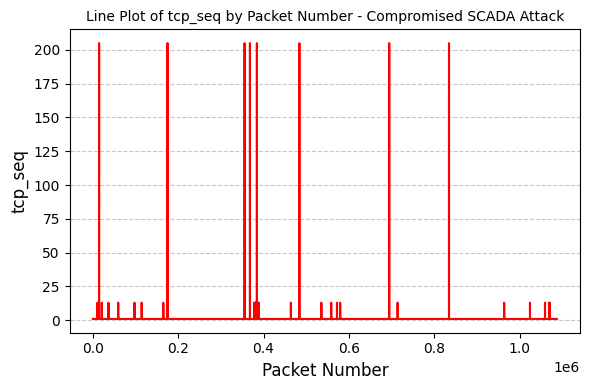

In [24]:
# Plot line plots for top features in attack data
for feature in top_feature_names:
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=attack_data_copy["packet_number"], y=attack_data[feature], color='red') # Put copy in x-axis to preserve original packet numbers for plotting
    plt.title(f'Line Plot of {feature} by Packet Number - Compromised SCADA Attack', fontsize=10)
    plt.xlabel("Packet Number", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

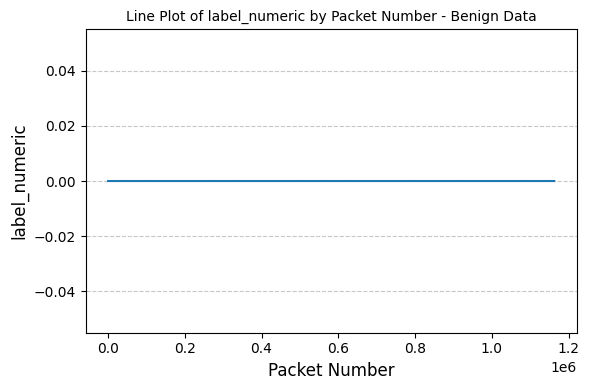

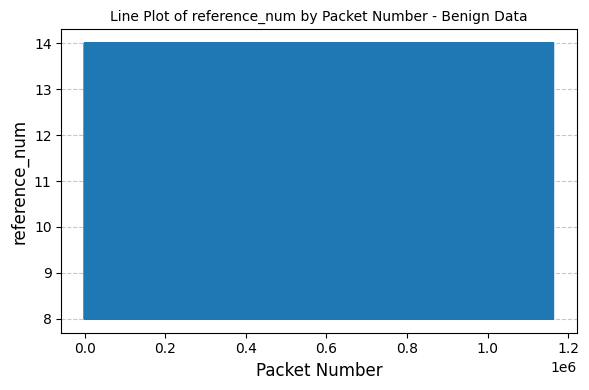

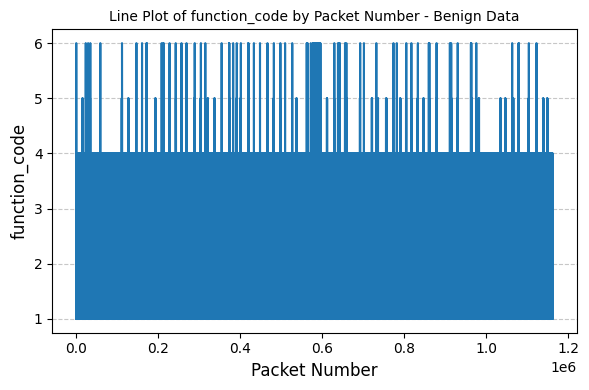

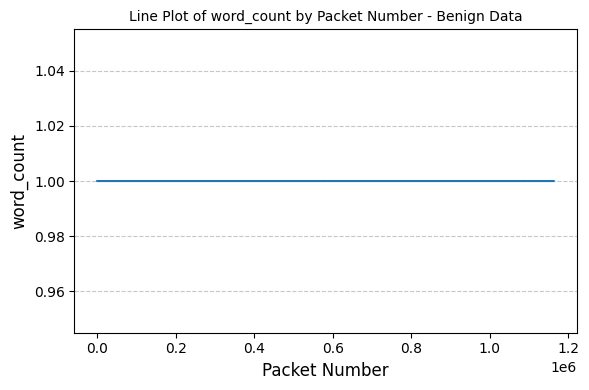

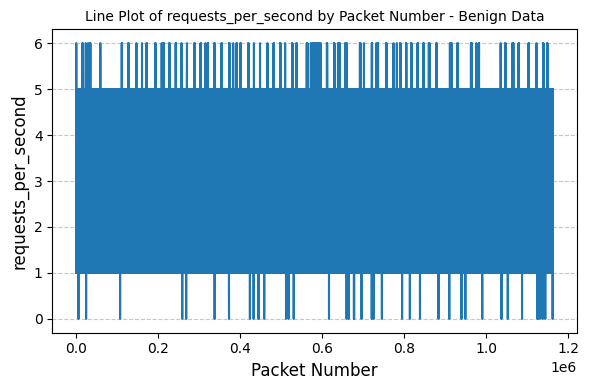

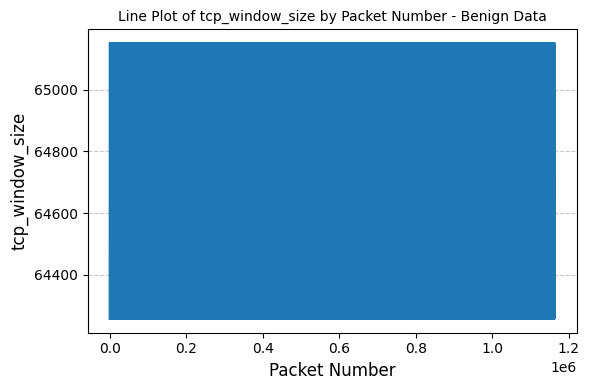

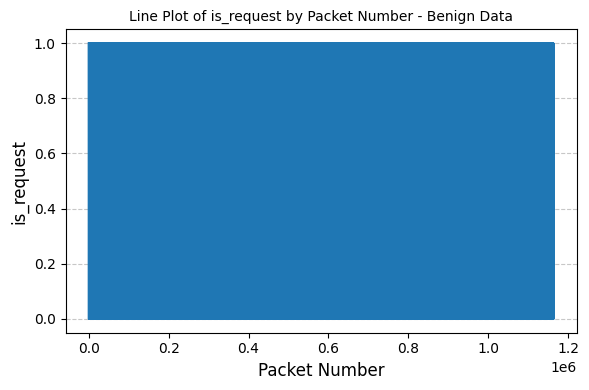

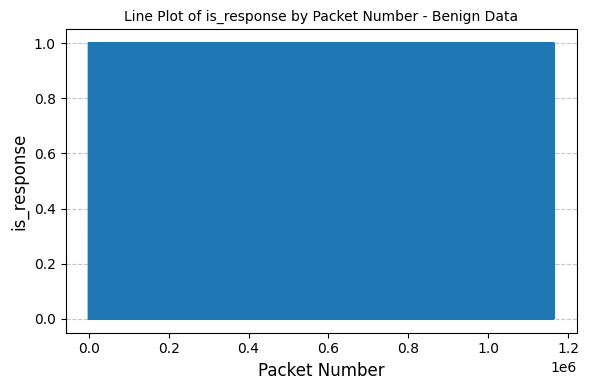

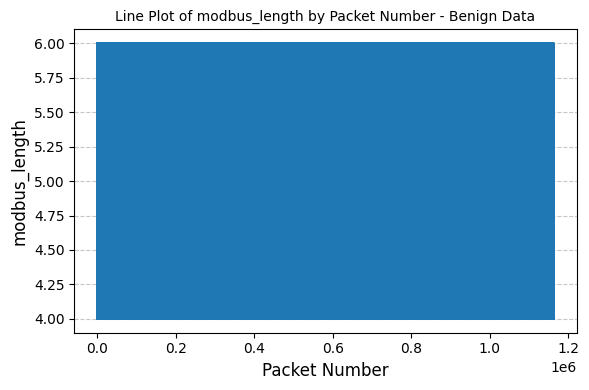

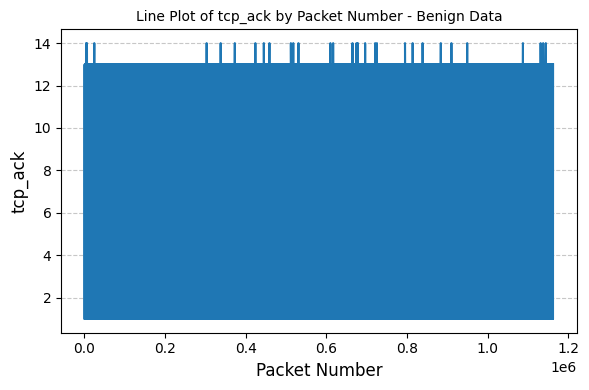

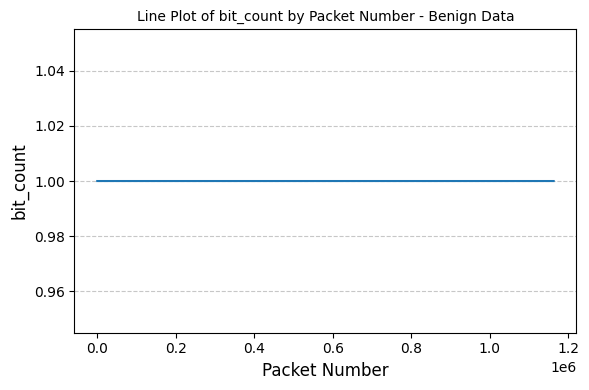

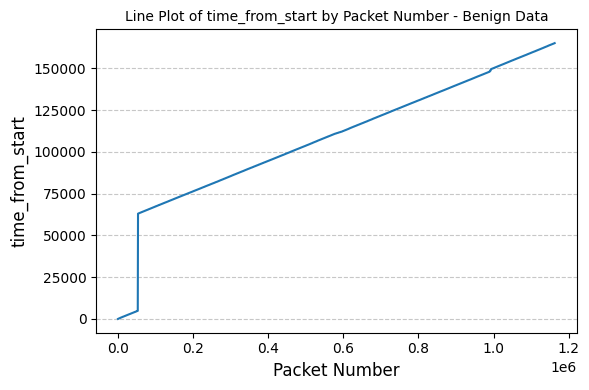

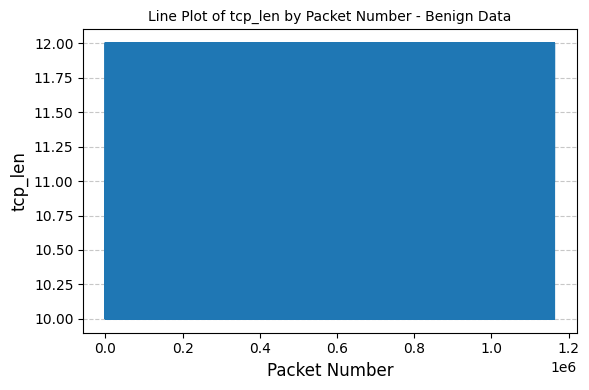

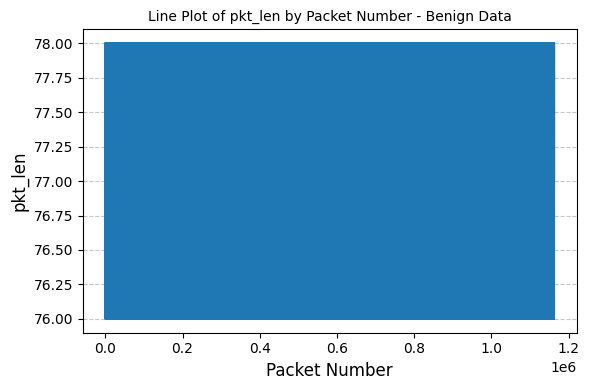

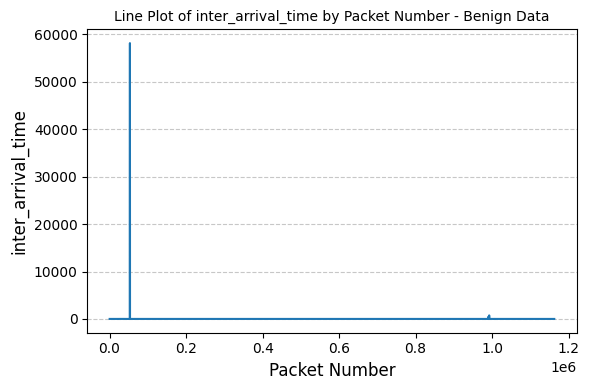

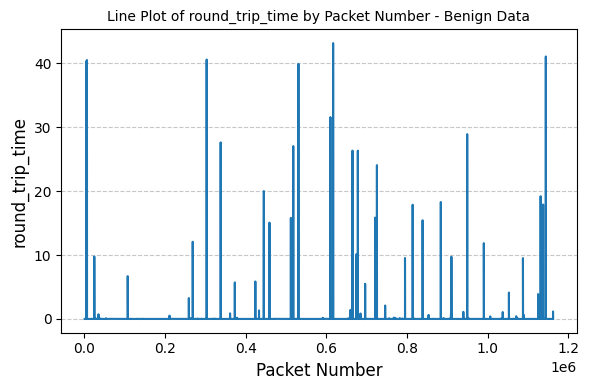

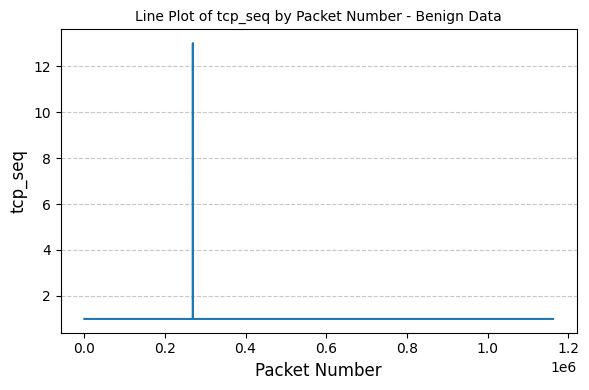

In [25]:
# Plot line plots for top features in benign data
for feature in top_feature_names:
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=benign_data["packet_number"], y=benign_data[feature]) # Put copy in x-axis to preserve original packet numbers for plotting
    plt.title(f'Line Plot of {feature} by Packet Number - Benign Data', fontsize=10)
    plt.xlabel("Packet Number", fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()